In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
from scipy.optimize import curve_fit

from uniformity_fit import *
from flatness import *
import csv
import tifffile as tiff
import os


In [18]:
def beam_centroid(img,):
    # coordinate grids
    y, x = np.indices(img.shape)

    I = img.astype(float)

    total_intensity = np.nansum(I)

    if total_intensity == 0:
        return None, None  # or fallback to max pixel

    x_centroid = np.nansum(I * x) / total_intensity
    y_centroid = np.nansum(I * y) / total_intensity


    return int(x_centroid), int(y_centroid)

def beam_area_mask(img, fraction, cx,cy):
    peak_val = np.nanmax(img)
    threshold = fraction * peak_val

    # mask of pixels above threshold
    mask = img >= threshold

    return mask

def plot_dose1(dosemap, im_type):
    h, w = dosemap.shape
    strip_width = 10

    if im_type == 'RCF':
        pixel_calibration = 0.08467  # mm/pixel
    elif im_type == "YAG":
        pixel_calibration = 27.9/ (1680-800)
    else:
        raise ValueError("Unknown im_type")

    # Beam centroid in pixel coordinates
    cx, cy = beam_centroid(dosemap)

    # Centered physical coordinates in mm
    x = (np.arange(w) - cx) * pixel_calibration
    y = (np.arange(h) - cy) * pixel_calibration

    dx = np.mean(np.diff(x))
    dy = np.mean(np.diff(y))

    # Use integer indices for slicing
    row0 = max(0, cy - strip_width // 2)
    row1 = min(h, cy + strip_width // 2)
    col0 = max(0, cx - strip_width // 2)
    col1 = min(w, cx + strip_width // 2)

    slice_row = np.mean(dosemap[row0:row1, :], axis=0)
    slice_col = np.mean(dosemap[:, col0:col1], axis=1)

    fig, ax_main = plt.subplots(figsize=(10, 6))

    # Image centered at (0, 0)
    im = ax_main.imshow(
        dosemap,
        origin="lower",
        aspect="equal",
        cmap="viridis",
        extent=[x[0], x[-1], y[0], y[-1]]
    )

    # Beam mask and contour
    mask = beam_area_mask(dosemap, 0.85, cx, cy)
    # if im_type == 'YAG':
        # ax_main.contour(x, y, mask.astype(float), levels=[0.5], colors='white', linewidths=1.6)

    ax_main.set_xlabel("X (mm)")
    ax_main.set_ylabel("Y (mm)")

    # Axes for slices and colorbar
    divider = make_axes_locatable(ax_main)
    ax_x = divider.append_axes("top", size="25%", pad=0.1, sharex=ax_main)
    ax_y = divider.append_axes("right", size="20%", pad=0.1, sharey=ax_main)
    cax  = divider.append_axes("right", size="2%", pad=0.1)

    # Fit the slices
    p0 = [np.max(slice_row)/2, 0, 5, 2,0,0]
    p00 = [np.max(slice_row),  6, 3,-1,0,0]


    params_x, _ = curve_fit(supergaussian1D_skewed, x, slice_row, p0=p0)
    params_y, _ = curve_fit(supergaussian1D_skewed, y, slice_col, p0=p0)

    params_xx, _ = curve_fit(sum_2gaussians_skewed, x, slice_row, p0=p00)
    params_yy, _ = curve_fit(sum_2gaussians_skewed, y, slice_col, p0=p00)
    sig_x, sig_y = params_x[2], params_y[2]
    P_x, P_y = params_x[3], params_y[3]
    r90_x, r90_y = abs(r90(sig_x, P_x)), abs(r90(sig_y, P_y))

    # Top plot: X slice
    ax_x.bar(x, slice_row, width=dx, alpha=0.7)
    
    ax_x.plot( x,supergaussian1D_skewed(x, *params_x),  'r-',label=f"SuperGaussian Fit (P={params_x[3]:.2f}, r90={r90_x:.2f})")
    ax_x.plot(x, sum_2gaussians_skewed(x, *params_xx), 'b-', label=f"2-Gaussian Fit (x0/sigma={abs(params_xx[1])/params_xx[2]:.2f})")
    if im_type == 'YAG':
        ax_x.set_ylabel("Intensity")
    elif im_type == 'RCF':
        ax_x.set_ylabel("Relative Dose")
    ax_x.legend(loc='lower left')
    plt.setp(ax_x.get_xticklabels(), visible=False)

    # Right plot: Y slice
    ax_y.barh(y, slice_col, height=dy, alpha=0.7)
    ax_y.plot(supergaussian1D_skewed(y, *params_y), y,  'r-',label=f"SuperGaussian Fit (P={params_y[3]:.2f}, r90={r90_y:.2f})")
    ax_y.plot(sum_2gaussians_skewed(y, *params_yy),y, 'b-', label=f"2-Gaussian Fit (x0/sigma={abs(params_yy[1])/params_yy[2]:.2f})")
    if im_type == 'YAG':
        ax_y.set_xlabel("Intensity")
    elif im_type == 'RCF':
        ax_y.set_xlabel("Relative Dose")
    ax_y.legend(loc='lower right')
    plt.setp(ax_y.get_yticklabels(), visible=False)

    # Colorbar
    if im_type == 'YAG':
        fig.colorbar(im, cax=cax, orientation='vertical', label="Intensity")
    elif im_type == 'RCF':
        fig.colorbar(im, cax=cax, orientation='vertical', label="Relative Dose")
    
    # Centered slice bands on main image
    rect_h = Rectangle(
        (x[0], y[row0]),
        x[-1] - x[0],
        (row1 - row0) * pixel_calibration,
        edgecolor="white", facecolor="none",linewidth=1.5,linestyle="--")

    rect_v = Rectangle(
        (x[col0], y[0]),
        (col1 - col0) * pixel_calibration,
        y[-1] - y[0],
        edgecolor="white",facecolor="none",linewidth=1.5,linestyle="--")

    ax_main.add_patch(rect_h)
    ax_main.add_patch(rect_v)

    # Make sure shared limits align
    ax_x.set_xlim(ax_main.get_xlim())
    ax_y.set_ylim(ax_main.get_ylim())
    return fig, cx, cy, params_x[3], params_y[3], r90_x, r90_y, abs(params_xx[1])/params_xx[2], abs(params_yy[1])/params_yy[2]


def dose_CLARA(PV,nOD0, channel):
    if channel ==0:
        a, b, c = 3.27, 16.9, -3.28
    elif channel ==1:
        a, b, c = 8.2, 10.9, -8.2
    elif channel ==2:
        a, b, c = 21.0, 14.0, -21.0

    OD = -np.log(PV/65535)
    nOD = OD - nOD0

    return a * (b*nOD) + c

In [3]:
channel = 0
if channel == 1:
    cmap = 'Greens'

elif channel ==0:
    cmap = "Reds"

OD0_green,OD0_red=np.float64(0.41037528937056844), np.float64(0.35893364827233415)

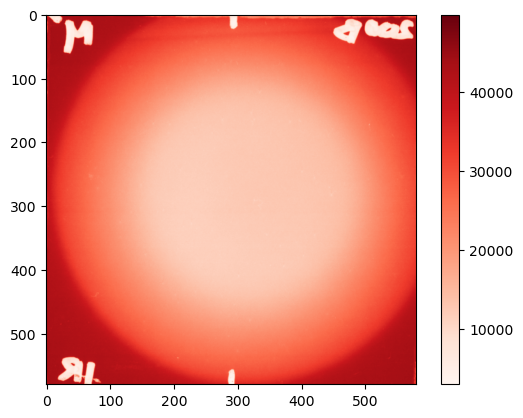

In [4]:
filename = 'CLARA_200B_M_2026_12_03'

film1 = np.load(f'CLARA_experiments/CLARA_films/Film Scans/individual/{filename}_film1.npy')
film2 = np.load(f'CLARA_experiments/CLARA_films/Film Scans/individual/{filename}_film2.npy')
film3 = np.load(f'CLARA_experiments/CLARA_films/Film Scans/individual/{filename}_film3.npy')
film4 = np.load(f'CLARA_experiments/CLARA_films/Film Scans/individual/{filename}_film4.npy')

plt.imshow(film1,cmap = cmap)
plt.colorbar()
# films.show()  # display image
# flipped_h = films.transpose(Image.FLIP_LEFT_RIGHT)

film_array = np.array(film1)


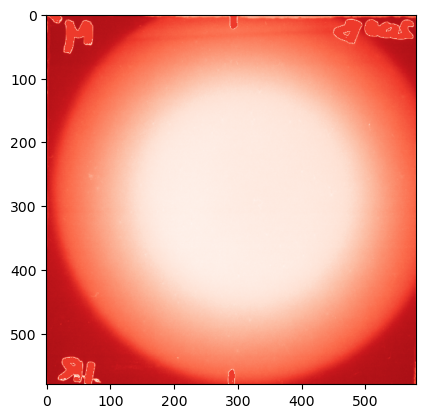

In [5]:
def remove_marking(film):
    h, w = film.shape
    mask = np.ones((h, w), dtype=bool)
    mask[65:-65, :] = False


    film[(mask) & (film < 12000)] = 35000
    plt.imshow(film,cmap = cmap)
    return film

film1 = remove_marking(film1)
film2 = remove_marking(film2)
film3 = remove_marking(film3)
film4 = remove_marking(film4)
plt.imshow(film1,cmap = cmap)

In [ ]:

# file_exists = os.path.isfile("CLARA_experiments/film_parameters.csv")

# with open("CLARA_experiments/film_parameters.csv", "a", newline="") as f:
#     writer = csv.writer(f)

#     if not file_exists:
#         writer.writerow([
#             "filename", "film",
#             "cx", "cy",
#             "P_x", "P_y",
#             "r90_x", "r90_y",
#             "x0_over_sigma_x", "x0_over_sigma_y"
#         ])

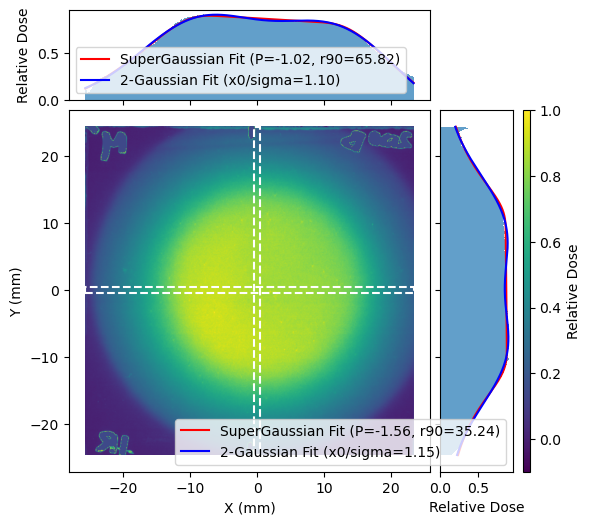

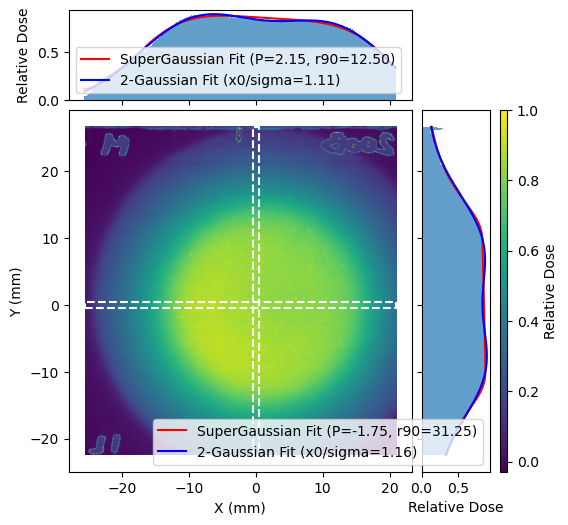

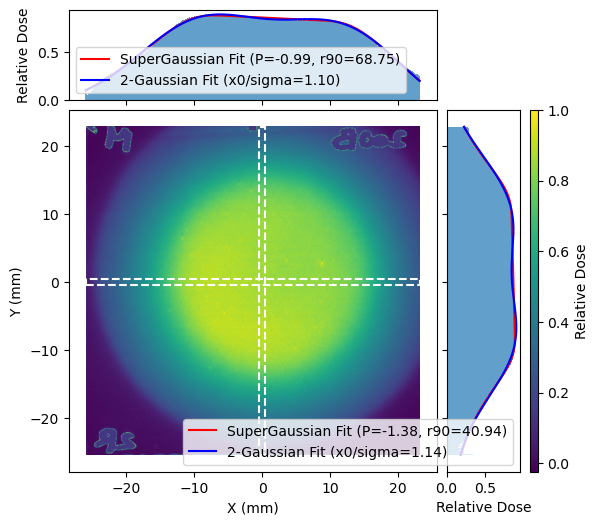

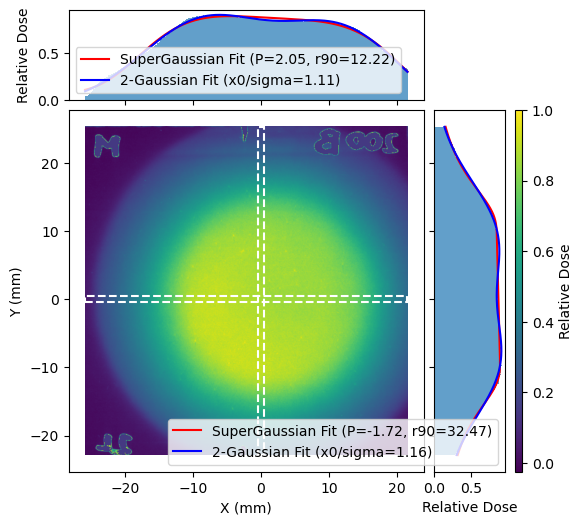

In [6]:
 

with open("CLARA_experiments/film_parameters.csv", "a", newline="") as f:
    writer = csv.writer(f)

    for i in range(1, 5):
        film = eval(f"film{i}")
        film_flipped = np.flipud(film)

        dose = dose_CLARA(film_flipped, OD0_red, channel)
        dose_norm = dose / np.max(dose)

        fig, cx, cy, Px, Py, r90_x, r90_y, ratio_x, ratio_y = plot_dose1(dose_norm, "RCF")

        # Optional: save figure
        out_name = f"{filename}_film{i}_dose_profile.png"
        # plt.savefig(f"CLARA_experiments/CLARA_output_figs/{out_name}")

        # writer.writerow([filename,f"film{i}", cx, cy, Px, Py, r90_x, r90_y, ratio_x, ratio_y])



Skipping already processed ('CLARA_200B_B_2026_12_03', 'film1')
Skipping already processed ('CLARA_200B_B_2026_12_03', 'film2')
Skipping already processed ('CLARA_200B_B_2026_12_03', 'film3')
Skipping already processed ('CLARA_200B_B_2026_12_03', 'film4')
Skipping already processed ('CLARA_200B_F_2026_12_03', 'film1')
Skipping already processed ('CLARA_200B_F_2026_12_03', 'film2')
Skipping already processed ('CLARA_200B_F_2026_12_03', 'film3')
Skipping already processed ('CLARA_200B_F_2026_12_03', 'film4')
Skipping already processed ('CLARA_200B_M_2026_12_03', 'film1')
Skipping already processed ('CLARA_200B_M_2026_12_03', 'film2')
Skipping already processed ('CLARA_200B_M_2026_12_03', 'film3')
Skipping already processed ('CLARA_200B_M_2026_12_03', 'film4')
Skipping already processed ('CLARA_200Q_B_2026_12_03', 'film1')
Skipping already processed ('CLARA_200Q_B_2026_12_03', 'film2')
Skipping already processed ('CLARA_200Q_B_2026_12_03', 'film3')
Skipping already processed ('CLARA_200Q_

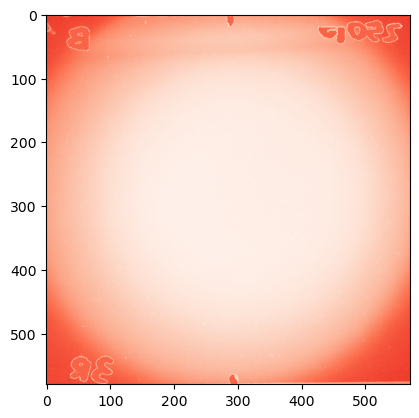

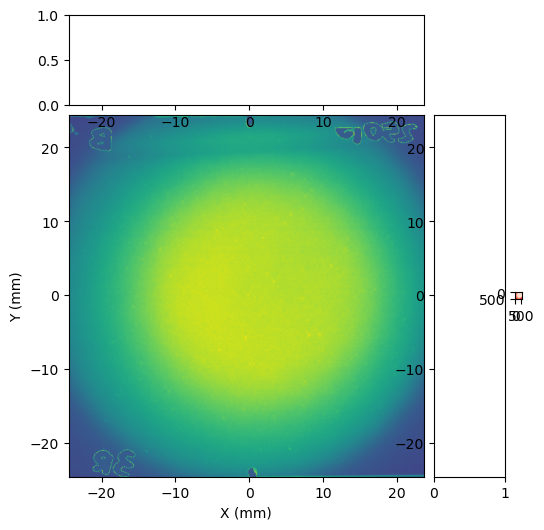

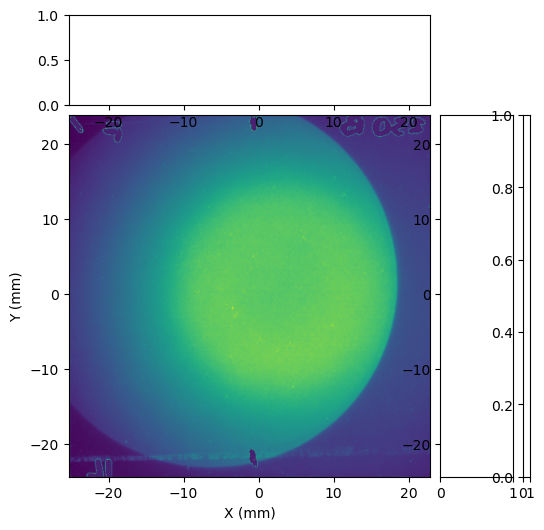

In [17]:
from pathlib import Path
import re

input_dir = Path("CLARA_experiments/CLARA_films/Film Scans/individual")
fig_dir = Path("CLARA_experiments/CLARA_output_figs")
csv_path = Path("CLARA_experiments/film_parameters.csv")

fig_dir.mkdir(parents=True, exist_ok=True)

pattern = re.compile(r"^(.*)_film([1-4])\.npy$")

film_groups = {}
for file_path in input_dir.glob("*.npy"):
    m = pattern.match(file_path.name)
    if m:
        base_name = m.group(1)
        film_num = int(m.group(2))
        film_groups.setdefault(base_name, {})[film_num] = file_path

# Load already processed rows so reruns skip them
done = set()
if csv_path.exists() and csv_path.stat().st_size > 0:
    with open(csv_path, "r", newline="") as f:
        reader = csv.reader(f)
        next(reader, None)  # skip header
        for row in reader:
            if len(row) >= 2:
                done.add((row[0], row[1]))  # (filename, film)

write_header = not csv_path.exists() or csv_path.stat().st_size == 0

with open(csv_path, "a", newline="") as f:
    writer = csv.writer(f)

    if write_header:
        writer.writerow([
            "filename", "film",
            "cx", "cy",
            "P_x", "P_y",
            "r90_x", "r90_y",
            "ratio_x", "ratio_y"
        ])

    for filename, films_dict in sorted(film_groups.items()):
        for i in range(1, 5):
            key = (filename, f"film{i}")
            if key in done:
                print(f"Skipping already processed {key}")
                continue

            if i not in films_dict:
                print(f"Missing {filename}_film{i}.npy")
                continue

            try:
                film = np.load(films_dict[i])
                film = remove_marking(film)
                film_flipped = np.flipud(film)

                dose = dose_CLARA(film_flipped, OD0_red, channel)
                dose_norm = dose / np.max(dose)

                fig, cx, cy, Px, Py, r90_x, r90_y, ratio_x, ratio_y = plot_dose1(dose_norm, "RCF")

                out_name = f"{filename}_film{i}_dose_profile.png"
                fig.savefig(fig_dir / out_name, dpi=300, bbox_inches="tight")
                plt.close(fig)

                writer.writerow([
                    filename, f"film{i}",
                    cx, cy,
                    Px, Py,
                    r90_x, r90_y,
                    ratio_x, ratio_y
                ])
                f.flush()  # make sure it is saved immediately

            except Exception as e:
                print(f"Failed on {filename} film{i}: {e}")
                try:
                    plt.close(fig)
                except:
                    pass
                continue

In [68]:
out_name


'CLARA_200S_M_2026_12_03_film4_dose_profile.png'